In [1]:
import pandas as pd
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, KFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import json

sys.path.insert(0, "../../utils")

from modules import *

enc = 'utf-8'

In [2]:
dataframe = pd.read_csv(f'../../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

In [4]:
dataframe.head()

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014-10,2014,10,-0.866,...,3,85,0,0,0,0,0,0,0,0
1,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014-10,2014,10,-0.866,...,5,42,29,8,5,42,1,0,1,2
2,nord,benoue,bibemi,bide,13.972945,9.422292,2014-10,2014,10,-0.866,...,0,9,1,0,0,1,1,0,0,1
3,nord,benoue,bibemi,dengui,13.642496,9.235656,2014-10,2014,10,-0.866,...,5,30,1,2,1,4,0,0,0,0
4,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014-10,2014,10,-0.866,...,0,25,2,3,0,5,0,0,0,0


In [5]:
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

In [6]:
dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [7]:
dataframe.drop(columns=['Case_UND5', 'Case_PRGN', 'Case_TOTAL',
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_OVR5' : 'cases'}, inplace=True)

In [8]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2014-10,-0.866,0.5,0.542311,0.148177,-0.365296,-0.148177,...,26.83,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,69
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2014-10,-0.866,0.5,0.499024,0.112709,-0.351063,-0.112709,...,25.50,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,33
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2014-10,-0.866,0.5,0.491692,0.119406,-0.338767,-0.119406,...,26.00,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,15
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2014-10,-0.866,0.5,0.511243,0.171523,-0.300408,-0.171523,...,27.33,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,12
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2014-10,-0.866,0.5,0.505574,0.198941,-0.280563,-0.198941,...,26.67,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,19


In [9]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [ ]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              #512, 
              #1024, 
              #2048, 
              #4096, 
              8192]

In [15]:
num_of_classes = len(bin_ranges) - 1
print(f"Number of classes: {num_of_classes}")

Number of classes: 8


<Axes: title={'center': 'cases Distribution'}, xlabel='Bins', ylabel='Frequency'>

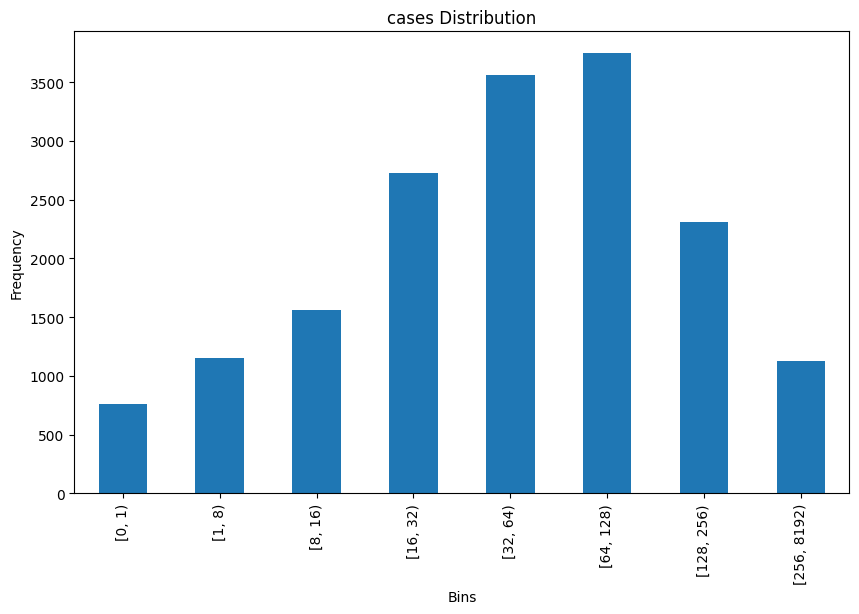

In [11]:
target_col = 'cases'

pd.cut(dataframe[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

In [16]:
risk_classes = list(range(0,num_of_classes))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7]

In [17]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [18]:
dataframe['case_bin'] = bins

In [19]:
dataset = dataframe.copy()

In [20]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [21]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256 8192]


In [22]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [23]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2014-10,-0.866,0.5,0.542311,0.148177,-0.365296,-0.148177,...,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,69,5
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2014-10,-0.866,0.5,0.499024,0.112709,-0.351063,-0.112709,...,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,33,4
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2014-10,-0.866,0.5,0.491692,0.119406,-0.338767,-0.119406,...,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,15,2
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2014-10,-0.866,0.5,0.511243,0.171523,-0.300408,-0.171523,...,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,12,2
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2014-10,-0.866,0.5,0.505574,0.198941,-0.280563,-0.198941,...,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,19,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16948,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-09,-1.000,0.0,0.444202,0.246985,-0.353127,-0.246985,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,25,3
16949,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-09,-1.000,0.0,0.594980,0.262238,-0.460305,-0.262238,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,46,4
16950,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-09,-1.000,0.0,0.592537,0.214245,-0.454020,-0.214245,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,330,7
16951,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-09,-1.000,0.0,0.599925,0.240514,-0.463363,-0.240514,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,197,6


In [24]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16953 entries, 0 to 16952
Data columns (total 70 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   location                 16953 non-null  object   
 1   x                        16953 non-null  float64  
 2   y                        16953 non-null  float64  
 3   dt_prediction            16953 non-null  period[M]
 4   month_sin                16953 non-null  float64  
 5   month_cos                16953 non-null  float64  
 6   ndvi                     16887 non-null  float64  
 7   ndmi                     16887 non-null  float64  
 8   ndwi                     16887 non-null  float64  
 9   ndbi                     16887 non-null  float64  
 10  ndvi_mean                16935 non-null  float64  
 11  ndmi_mean                16935 non-null  float64  
 12  ndwi_mean                16935 non-null  float64  
 13  ndbi_mean                16935 non-null  float

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
import pickle
from Model_Validation_Module import *

In [26]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# y_test.value_counts().sort_index().plot(kind='bar', figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

In [29]:
# scaler = MinMaxScaler(feature_range = (-1, 1))
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [30]:
imputer = KNNImputer(n_neighbors=3)
imputer.fit(X_train_scaled)
X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [31]:
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

In [32]:
X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

In [33]:
with open("CM_Nord_gridcv_best_params_ovr5.json", "r") as f:
    model_params = json.load(f)

In [34]:
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 0)
rfe = RFECV(xgb.XGBRegressor(**model_params), step=1, cv=cv, scoring = 'neg_mean_squared_error',  n_jobs=-1)
fitted_rfe = rfe.fit(X_train_imputed, y_train)

In [35]:
fitted_rfe

RFECV(cv=StratifiedKFold(n_splits=10, random_state=0, shuffle=True),
      estimator=XGBRegressor(base_score=None, booster=None, callbacks=None,
                             colsample_bylevel=None, colsample_bynode=None,
                             colsample_bytree=None, device=None,
                             early_stopping_rounds=None,
                             enable_categorical=False, eval_metric=None,
                             feature_types=None, gamma=0.1, grow_policy=None,
                             importance_type=None, interaction_constraints=None,
                             learning_rate=0.1, max_bin=None,
                             max_cat_threshold=None, max_cat_to_onehot=None,
                             max_delta_step=None, max_depth=7, max_leaves=None,
                             min_child_weight=3, missing=nan,
                             monotone_constraints=None, multi_strategy=None,
                             n_estimators=300, n_jobs=None,
                             num_parallel_tree=None, random_state=None, ...),
      n_jobs=-1, scoring='neg_mean_squared_error')

In [36]:
with open("CM_Nord_rfecv_model_ovr5.pkl", "wb") as f:
    pickle.dump(fitted_rfe, f)

In [37]:
X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

In [38]:
features_chosen = X_train_rfe.columns.to_list()

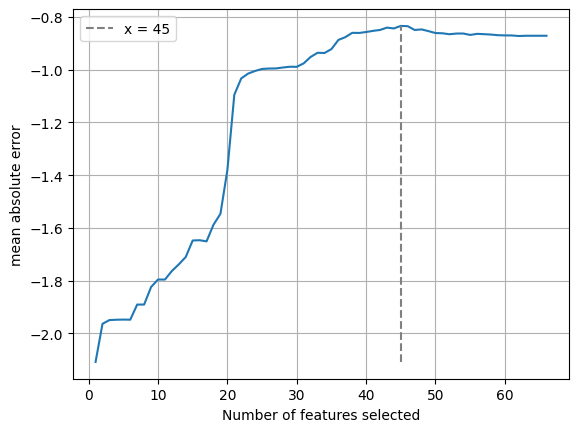

In [39]:
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("mean absolute error")
plt.plot(range(1,len(fitted_rfe.cv_results_['mean_test_score']) + 1), fitted_rfe.cv_results_['mean_test_score'])
plt.vlines(x = np.argmax(fitted_rfe.cv_results_['mean_test_score'])+1,
                   ls='--', ymin = np.min(fitted_rfe.cv_results_['mean_test_score']),
                   ymax = np.max(fitted_rfe.cv_results_['mean_test_score']), colors = 'grey',
                   label = 'x = '+str(np.argmax(fitted_rfe.cv_results_['mean_test_score'])+1))
plt.grid()
plt.legend()
plt.show()

In [40]:
model = xgb.XGBRegressor(**model_params)

In [41]:
fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

In [42]:
y_train_proba = fitted_model.predict(X_train_rfe)
y_test_proba = fitted_model.predict(X_test_rfe)

In [43]:
y_train_pred = np.clip(np.round(y_train_proba), 0, num_of_classes-1).astype(int)
y_test_pred = np.clip(np.round(y_test_proba), 0, num_of_classes-1).astype(int)


In [44]:
results_train = pd.DataFrame({'actual': y_train,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [45]:
metrics(results_train, results_test, threshold=1)

MAE on train set: 0.2979
MSE on train set: 0.3258
min prediction: 0
max prediction: 7

MAE on test set: 0.6323
MSE on test set: 0.8983
Error <= 1: 91.15 %
min prediction: 0
max prediction: 7


In [46]:
len(features_chosen)

45

In [47]:
features_chosen

['x',
 'y',
 'month_sin',
 'month_cos',
 'rainfall',
 'rainfall_acc_prev_month',
 'distance_to_coast',
 'distance_to_river',
 'slope_mean_1km',
 'aspect_mean_200m',
 'elevation_mean_1km',
 'hillshade_mean_1km',
 'fs_area_1km',
 'flow_accu_200m',
 'distance_to_coast_std',
 'distance_to_river_std',
 'slope_mean_1km_std',
 'aspect_mean_200m_std',
 'elevation_mean_1km_std',
 'hillshade_mean_1km_std',
 'flow_accu_200m_std',
 'lc_prop1',
 'lc_prop2',
 'lc_type3',
 'lc_type4',
 'lc_type5',
 'bio1',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19']

In [48]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mae',
    title='MAE per Risk Class'
)

In [49]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_prediction',
    group_by='month',
    metric='mae',
    title='Monthly MAE'
)

In [50]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    date_col='dt_temp',
    group_by='year',
    metric='mae',
    title='Yearly MAE'
)

In [51]:
plot_hist_plotly(results_test['actual'].cat.codes, results_test['prediction'])